In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
import mlflow.sklearn


from src.data_preparation import clean_data
from src.feature_engineering import add_features
from src.preprocessing import build_preprocessor

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/House_Prices.csv")

In [3]:
df = clean_data(df)
df = add_features(df)

In [4]:
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

In [5]:
preprocessor = build_preprocessor(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [8]:
mlflow.set_tracking_uri(
    "sqlite:////home/elgmouri/projects/aqari/mlflow.db"
)
mlflow.set_experiment("Aqari Model Comparison")
with mlflow.start_run(run_name="Final Gradient Boosting"):
    gradient_boosting_pipeline.fit(X_train, y_train)
    y_pred = gradient_boosting_pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)


    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    mlflow.sklearn.log_model(
        gradient_boosting_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

2026/09/28 14:13:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [9]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 14531.808750105632
RMSE: 20072.89440595186
R²: 0.9270563038889157


In [10]:
model = gradient_boosting_pipeline.named_steps["model"]
preprocessor = gradient_boosting_pipeline.named_steps["preprocessor"]

In [11]:
feature_names = preprocessor.get_feature_names_out()

In [12]:
importances = model.feature_importances_

In [13]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [14]:
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
35,num__TotalArea,0.437053
2,num__OverallQual,0.304866
36,num__TotalBathrooms,0.034423
24,num__GarageCars,0.025525
37,num__HouseAge,0.023314
7,num__BsmtFinSF1,0.017078
12,num__2ndFlrSF,0.016163
202,cat__BsmtQual_Ex,0.016141
14,num__GrLivArea,0.013733
1,num__LotArea,0.012132


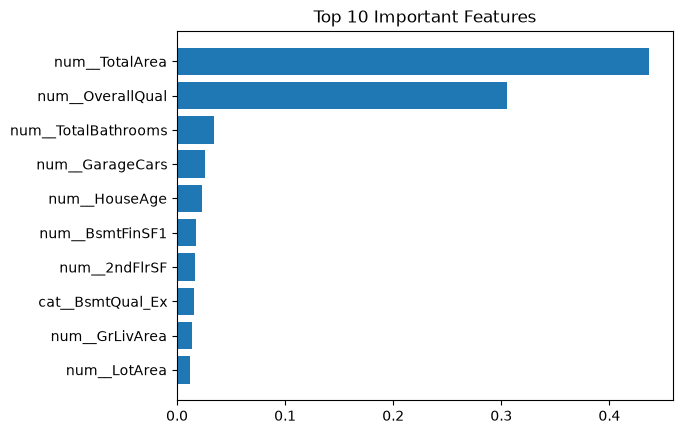

In [15]:
top10 = importance_df.head(10)

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

The feature importance analysis shows which variables had the strongest influence on the final Gradient Boosting predictions.

The most important features should be compared with the patterns observed during EDA.